# Loading

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [135]:
BASEDIR = "../LOGS"

runs = pd.read_csv(os.path.join(BASEDIR, "runs.csv"))
search_info = pd.read_csv(os.path.join(BASEDIR, "search_settings.csv"))
dataset_info = pd.read_csv(os.path.join(BASEDIR, "dataset_settings.csv"))
index_info = pd.read_csv(os.path.join(BASEDIR, "index_settings.csv"))

# Join the three settings dataframes on dataset_file
info = search_info.join(dataset_info.set_index('dataset_file'), on='dataset_file', how='left', rsuffix='_dataset')
info = info.join(index_info.set_index('index_file'), on='index_file', how='left', rsuffix='_index')

# Join the two dataframes where runs['settings_id'] is the id of the search settings
df = pd.merge(runs, info, left_on='settings_id', right_on='id', how='left', suffixes=('_run', '_settings'))

print(df.columns)

df.head()

Index(['id_run', 'settings_id', 'query_id', 'query_length', 'query_channels',
       'result_set_ts_indices', 'result_set_ts_positions',
       'result_set_distances', 'num_leaves_visited', 'num_nodes_visited',
       'num_ts_examined', 'total_time_s', 'first_layer_time_s',
       'tree_traversal_time_s', 'io_time_s', 'ts_examination_time_s',
       'id_settings', 'index_file', 'dataset_file', 'ffts_file', 'query_file',
       'num_queries', 'query_type', 'r_range_r', 'knn_k', 'exact',
       'normalized', 'search_method', 'distance_measure', 'id_dataset',
       'series_length', 'num_channels', 'num_series', 'id_index',
       'dataset_file_index', 'ffts_file_index', 'l_min', 'l_max',
       'normalized_index', 'index_type', 'segment_length', 'pos_per_env',
       'first_layer_num_bits', 'leaf_capacity', 'breakpoint_strategy',
       'split_strategy', 'min_num_bits_on_tie', 'num_bits_limit',
       'indexing_time_s', 'fft_calc_time_s'],
      dtype='object')


,id_run,settings_id,query_id,query_length,query_channels,result_set_ts_indices,result_set_ts_positions,result_set_distances,num_leaves_visited,num_nodes_visited,...,segment_length,pos_per_env,first_layer_num_bits,leaf_capacity,breakpoint_strategy,split_strategy,min_num_bits_on_tie,num_bits_limit,indexing_time_s,fft_calc_time_s
0,0,0,0,512,1;0;1;1,1,322,0.318006,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,1,512,1;1;1;1,31,299,0.301724,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0,2,1024,1;0;1;1,110,0,0.154127,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0,3,730,1;1;1;1,171,154,0.316969,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0,4,1024,1;0;0;1,172,0,0.257429,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [137]:
# Infer necessary columns
ALGOS = ['BRUTE_FORCE', 'MASS', 'MULISSE']

# Algorithm -- dependent on combinations of search method and distance measure
def get_algorithm(row):
    search_method = row.search_method
    distance_measure = row.distance_measure
    ffts_precomputed = not pd.isna(row.ffts_file)

    if 'scan' in search_method and distance_measure == 'ed' and not ffts_precomputed:
        return 'BRUTE_FORCE'
    elif 'scan' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MASS'
    elif 'isax' in search_method and distance_measure == 'ed':
        return 'MULISSE_ED'
    elif 'isax' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MULISSE'
    else:
        return np.nan
    
df['algorithm'] = df.apply(get_algorithm, axis=1)

df['dataset'] = df.dataset_file.str.extract(r'(\w+).bin')

df['num_query_channels'] = df.query_channels.str.count('1')

df[['algorithm', 'dataset', 'num_query_channels']]

,algorithm,dataset,num_query_channels
0,BRUTE_FORCE,rwalk_N5000_C4_M1024,3
1,BRUTE_FORCE,rwalk_N5000_C4_M1024,4
2,BRUTE_FORCE,rwalk_N5000_C4_M1024,3
3,BRUTE_FORCE,rwalk_N5000_C4_M1024,4
4,BRUTE_FORCE,rwalk_N5000_C4_M1024,2
...,...,...,...
1195,MASS,rwalk_N5000_C4_M1024,3
1196,MASS,rwalk_N5000_C4_M1024,3
1197,MASS,rwalk_N5000_C4_M1024,2
1198,MASS,rwalk_N5000_C4_M1024,1


# Test

In [139]:
view = df[
    (df.algorithm.isna() == False) &
    (df.dataset == 'rwalk_N5000_C4_M1024') &
    ((~df.algorithm.str.contains("MULISSE")) | (df.query_length >= df.l_min))
]

view.groupby(['algorithm', 'query_length', 'num_query_channels']).size().unstack()

num_query_channels         1   2   3   4
algorithm   query_length                
BRUTE_FORCE 512           27  26  19  28
            730           24  17  30  29
            1024          28  29  21  22
MASS        512           27  26  19  28
            730           24  17  30  29
            1024          28  29  21  22
MULISSE     512           27  26  19  28
            730           24  17  30  29
            1024          28  29  21  22
MULISSE_ED  512           27  26  19  28
            730           24  17  30  29
            1024          28  29  21  22

In [140]:
view.groupby(['algorithm', 'query_length', 'num_query_channels']).total_time_s.median().unstack()

num_query_channels               1         2          3          4
algorithm   query_length                                          
BRUTE_FORCE 512           4.186081  7.644368  11.480794  15.017729
            730           3.407106  6.337580   9.387313  12.538464
            1024          0.038862  0.060116   0.083983   0.107523
MASS        512           0.404240  0.756586   1.085554   1.509552
            730           0.390145  0.757347   1.111502   1.461225
            1024          0.370228  0.730069   1.048435   1.525294
MULISSE     512           0.350560  0.614465   0.845721   0.979466
            730           0.330537  0.496474   0.632526   0.670323
            1024          0.139748  0.103804   0.052110   0.040749
MULISSE_ED  512           0.483742  1.496213   1.881875   2.778421
            730           0.457510  0.852493   1.446990   1.555922
            1024          0.017473  0.015301   0.013470   0.013381

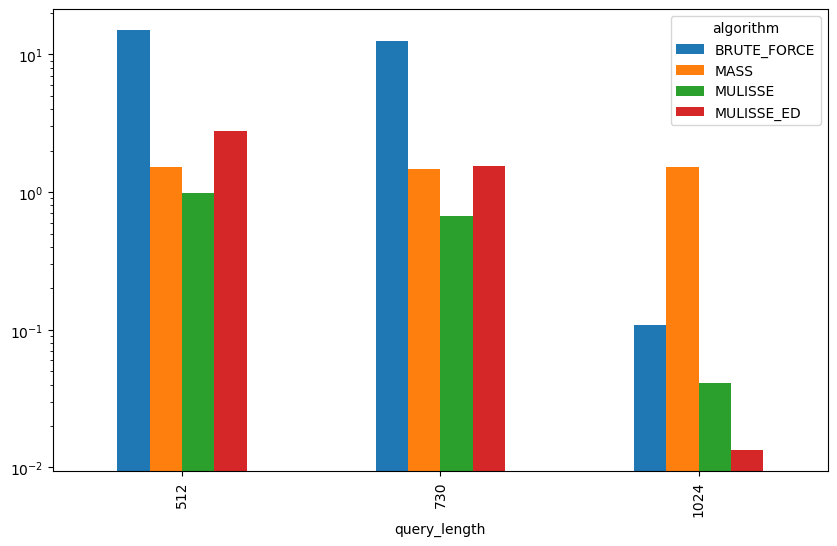

In [141]:
fig, ax = plt.subplots(figsize=(10, 6))

view[view['num_query_channels'] == 4].groupby(['query_length', "algorithm"]).total_time_s.median().unstack().plot(kind='bar', ax=ax)

ax.set_yscale("log")

In [142]:
view.groupby(['algorithm', 'query_length', 'num_query_channels']).num_ts_examined.median().unstack()

num_query_channels             1       2       3       4
algorithm   query_length                                
BRUTE_FORCE 512           5000.0  5000.0  5000.0  5000.0
            730           5000.0  5000.0  5000.0  5000.0
            1024          5000.0  5000.0  5000.0  5000.0
MASS        512           5000.0  5000.0  5000.0  5000.0
            730           5000.0  5000.0  5000.0  5000.0
            1024          5000.0  5000.0  5000.0  5000.0
MULISSE     512           4483.0  3925.5  3605.0  3269.0
            730           4119.5  3341.0  2748.0  2134.0
            1024          1691.5   448.0   220.0    96.0
MULISSE_ED  512           4483.0  3925.5  3605.0  3269.0
            730           4119.5  3341.0  2748.0  2134.0
            1024          1691.5   448.0   220.0    96.0